1. Library import and data extraction

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import glob
import os

def load_and_aggregate_fits(file_pattern):
    """Loads fitted CSV files and calculates Mean across replicates."""
    all_fits = []
    files = glob.glob(file_pattern)
    if not files:
        print(f"No files found matching: {file_pattern}")
        return None, None

    print(f"Loading {len(files)} fitted replicate files...")
    for file in files:
        df = pd.read_csv(file)
        all_fits.append(df.select_dtypes(include=[np.number]))

    combined = np.array([df.values for df in all_fits])
    mean_data = np.mean(combined, axis=0)
    column_names = all_fits[0].columns
    return mean_data, column_names

def load_raw_datapoints(file_pattern):
    """Loads raw data point CSV files (all replicates)."""
    all_datapoints = []
    files = glob.glob(file_pattern)
    if not files:
        print(f"No files found matching: {file_pattern}")
        return None

    print(f"Loading {len(files)} raw data point files...")
    for file in files:
        df = pd.read_csv(file)
        all_datapoints.append(df)
    
    return all_datapoints

# === Main workflow ===
# Step 1: Load fitted CSVs for averaging
fits_folder = input("Enter the directory path containing FITTED replicate CSVs: ")
fits_search = os.path.join(fits_folder, "*.csv")
mean_vals, cols = load_and_aggregate_fits(fits_search)

if mean_vals is None:
    print("Error loading fitted files. Exiting.")
    exit()

# Step 2: Load raw data points
datapoints_folder = input("\nEnter the directory path containing RAW DATA POINT CSVs: ")
datapoints_search = os.path.join(datapoints_folder, "*.csv")
raw_datapoints = load_raw_datapoints(datapoints_search)

if raw_datapoints is None:
    print("Error loading raw data point files. Exiting.")
    exit()

# 3. Detect Indices in fitted data
time_idx = [i for i, col in enumerate(cols) if "time" in col.lower()][0]
sub_idx = [i for i, col in enumerate(cols) if "substrate" in col.lower()][0]
prox_indices = [i for i, col in enumerate(cols) if "proximal product" in col.lower()]
dist_indices = [i for i, col in enumerate(cols) if "distal product" in col.lower()]

time_data = mean_vals[:, time_idx]
n_prox = len(prox_indices)
n_dist = len(dist_indices)
n_raw_files = len(raw_datapoints)

# Get the maximum time point
max_time = time_data.max()
print(f"\nMaximum time point: {max_time}")
print(f"Number of raw data files: {n_raw_files}")




Loading 3 fitted replicate files...
Loading 3 raw data point files...

Maximum time point: 2640.0
Number of raw data files: 3


2. Ploting Data

Plot saved to: C:\Users\uzair\OneDrive - Vilnius University\Documents\Ph.D. Research\New Gels Data\A_VS_G\Analyzed Data\A_V_G fitted cy5.pdf


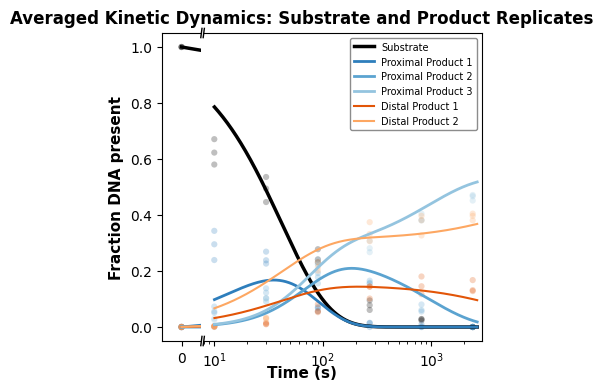

In [2]:
# 4. Setup Figure with Broken X-Axis - TRUE SQUARE 4x4"
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, facecolor='w', 
                               figsize=(4, 4), 
                               gridspec_kw={'width_ratios': [0.5, 3.5]})
plt.subplots_adjust(wspace=0.015, left=0.15, right=0.95, top=0.92, bottom=0.15)

# 5. Plotting Logic - Raw data points + Mean fit line
def plot_datapoints_and_mean(target_ax, is_log_axis):
    mask = time_data >= 10 if is_log_axis else time_data < 10
    t_plot = time_data[mask]
    
    # Define color maps for proximal and distal products (For Cy3 proximal=Oranges, distal= Blues)
    colors_prox = plt.cm.Blues_r(np.linspace(0.3, 0.6, n_prox))
    colors_dist = plt.cm.Oranges_r(np.linspace(0.3, 0.6, n_dist))
    #colors_prox = plt.cm.Oranges_r(np.linspace(0.3, 0.6, n_prox))
    #colors_dist = plt.cm.Blues_r(np.linspace(0.3, 0.6, n_dist))
    
    def add_trace(idx, color, label, linestyle='-', linewidth=2):
        # Plot raw data points from all replicate files
        for raw_df in raw_datapoints:
            # Try to find matching columns in raw data
            # Assume raw data has same column structure
            try:
                t_raw = raw_df.iloc[:, time_idx].values
                y_raw = raw_df.iloc[:, idx].values
                
                # Apply mask for this panel
                if is_log_axis:
                    raw_mask = t_raw >= 10
                else:
                    raw_mask = t_raw < 10
                
                # Plot individual raw data points (semi-transparent)
                target_ax.scatter(t_raw[raw_mask], y_raw[raw_mask], 
                                color=color, alpha=0.25, s=20, zorder=1, 
                                edgecolors='none')
            except:
                # Skip if column doesn't exist in raw data
                pass
        
        # Plot mean fit line from fitted data (solid and opaque)
        m = mean_vals[mask, idx]
        target_ax.plot(t_plot, m, linestyle=linestyle, color=color, 
                      label=label, linewidth=linewidth, zorder=3, alpha=1.0)

    # Substrate
    add_trace(sub_idx, 'black', 'Substrate', linestyle='-', linewidth=2.5)

    # Proximal Products
    for i, col_idx in enumerate(prox_indices):
        add_trace(col_idx, colors_prox[i], f'Proximal Product {i+1}', linestyle='-', linewidth=2)

    # Distal Products 
    for i, col_idx in enumerate(dist_indices):
        add_trace(col_idx, colors_dist[i], f'Distal Product {i+1}', linestyle='-', linewidth=1.5)

plot_datapoints_and_mean(ax1, is_log_axis=False)
plot_datapoints_and_mean(ax2, is_log_axis=True)

# 6. Axis Limits and Scaling - X-axis ends at max timepoint
ax1.set_xlim(-0.5, 0.5)
ax1.set_xticks([0])
ax1.set_xticklabels(['0'])
ax1.set_ylabel("Fraction DNA present", fontsize=11, fontweight='bold')

ax2.set_xscale('log')
ax2.set_xlim(8, max_time * 1.1)  # Ends at actual max time with 10% padding

# Dynamically set x-ticks based on max_time
tick_values = [10]
current_tick = 10
while current_tick < max_time:
    current_tick *= 10
    if current_tick <= max_time * 1.2:
        tick_values.append(current_tick)

ax2.set_xticks(tick_values)

# 7. Broken Axis Styling
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False)

d = .015 
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes) 
ax2.plot((-d/7, +d/7), (-d, +d), **kwargs)
ax2.plot((-d/7, +d/7), (1-d, 1+d), **kwargs)

# 8. Final Titles and Legend INSIDE upper right
fig.suptitle("Averaged Kinetic Dynamics: Substrate and Product Replicates", 
             fontsize=12, fontweight='bold')
fig.text(0.5, 0.06, "Time (s)", ha='center', fontsize=11, fontweight='bold')

# Legend inside upper right corner (only shows mean lines)
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, loc='upper right', fontsize=7, frameon=True, 
          framealpha=0.9, edgecolor='gray')
# 9. Save Logic
save_path = input("\nEnter save path (e.g., final_plot_with_datapoints.pdf) or Enter to skip: ")
if save_path.strip():
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['pdf.fonttype'] = 42 
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Plot saved to: {save_path}")

plt.show()